# Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)

#create images folder
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png" , resolution=300):
    path=os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

#Ignore uselss warnings
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

# Download and load the data

In [3]:
# CELL 2: Get the Data (Fixed Extraction Path)
import tarfile
import urllib.request
import shutil

DOWNLOAD_ROOT = "https://github.com/ageron/data/raw/main/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    # 1. Clean up: Reset the folder to avoid conflicts
    if os.path.exists(housing_path):
        shutil.rmtree(housing_path)
    
    # 2. Create the directory
    os.makedirs(housing_path)
    
    # 3. Download the file
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    
    # 4. Extract
    housing_tgz = tarfile.open(tgz_path)
    
    # FIX: Extract to the PARENT directory ("datasets")
    # Since the zip file already contains a folder named "housing",
    # extracting it to "datasets" will result in "datasets/housing/housing.csv"
    parent_path = os.path.dirname(housing_path) 
    # 'filter' argument silences the warning
    housing_tgz.extractall(path=parent_path, filter='data')
    
    housing_tgz.close()

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

# Run the function
fetch_housing_data()

# Load the data
housing = load_housing_data()

# Show top 5 rows
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Sampling bias

In [4]:
# CELL 3: Create Stratified Test Set
from sklearn.model_selection import StratifiedShuffleSplit

# 1. Create the income category attribute (bins) to stratify on
# We create 5 categories (1 to 5) for median income
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

# 2. Split the data using StratifiedShuffleSplit
# This ensures the test set has the same income distribution as the full data
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

# 3. Drop the income_cat attribute so the data is back to its original state
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# 4. Verify it worked
print(f"Training set size: {len(strat_train_set)}")
print(f"Test set size: {len(strat_test_set)}")

Training set size: 16512
Test set size: 4128


# Exploration Setup

In [5]:
# Create a copy of the training set so we can play with it without harming the original
housing = strat_train_set.copy()

# Visualizing Geographical Data

Saving figure better_visualization_plot
Saving figure housing_prices_scatterplot


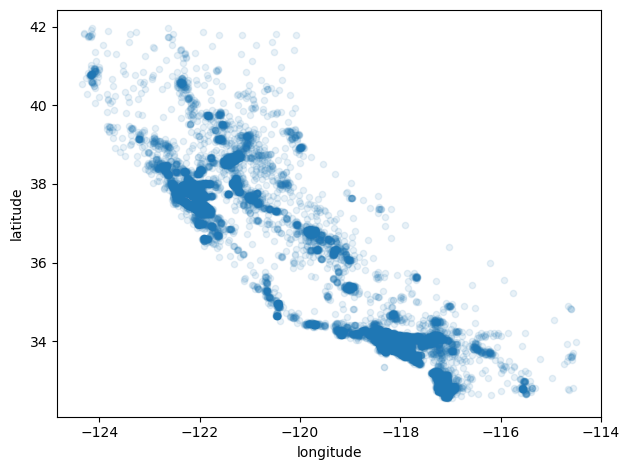

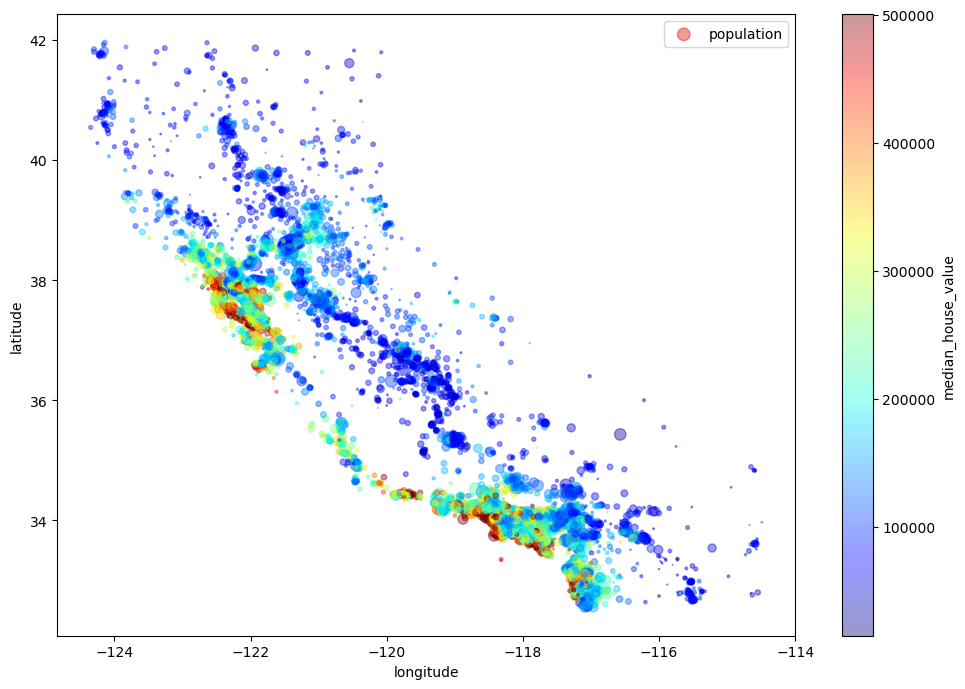

In [6]:
# 1. Basic scatter plot (hard to see density)
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)
save_fig("better_visualization_plot")

# 2. Advanced scatter plot (showing population and price)
# s = radius of circle (population), c = color (price), cmap = jet (blue to red color map)
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=housing["population"]/100, label="population", figsize=(10,7),
    c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()
save_fig("housing_prices_scatterplot")

# Looking for Correlations

In [7]:
# We calculate the standard correlation coefficient (Pearson's r)
# The 'numeric_only=True' argument ensures we don't try to calculate correlations on text columns
corr_matrix = housing.corr(numeric_only=True)

# Let's look at how much each attribute correlates with the median house value
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


# Feature Engineering

In [ ]:
# Create new features that might be more useful than the raw data
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]

# Check the correlation matrix again to see if our new features are better
corr_matrix = housing.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

# Separate Predictors and Labels

In [8]:
# 'housing' will be our features (we drop the median_house_value column)
housing = strat_train_set.drop("median_house_value", axis=1)

# 'housing_labels' will be the answers we want to predict
housing_labels = strat_train_set["median_house_value"].copy()

# Custom Transformer for Feature Engineering

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin

# These are the column indices in the dataset
# (col 3=rooms, 4=bedrooms, 5=population, 6=households)
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True): # no *args or **kwargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    
    def fit(self, X, y=None):
        return self  # nothing else to do
    
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            # numpy.c_ concatenates columns
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

# The Full Processing Pipeline

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 1. Define the pipeline for NUMERICAL attributes
#    - First, fill missing values with the median
#    - Next, add our custom features (bedrooms_per_room, etc.)
#    - Finally, scale everything (Standardization)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])

# 2. Separate the numerical column names from the categorical column name
#    (We drop "ocean_proximity" to get just the number columns)
housing_num = housing.drop("ocean_proximity", axis=1)
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

# 3. Create the full pipeline (ColumnTransformer)
#    - Apply 'num_pipeline' to number columns
#    - Apply 'OneHotEncoder' to the text column
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

# 4. Run the whole pipeline!
housing_prepared = full_pipeline.fit_transform(housing)

print("Data shape after processing:", housing_prepared.shape)

Data shape after processing: (16512, 16)


# Train Linear Regression

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Initialize and Train
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

# 2. Test it on a few instances from the training set to see it in action
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))
print("Labels:     ", list(some_labels))

# 3. Measure RMSE on the whole training set
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
print(f"Linear Regression RMSE: ${lin_rmse:.2f}")

Predictions: [276608.27419651 333603.0303772  118237.5726011  108255.75159886
 308943.82732346]
Labels:      [458300.0, 483800.0, 101700.0, 96100.0, 361800.0]
Linear Regression RMSE: $67769.12


# Train Decision Tree


In [12]:
from sklearn.tree import DecisionTreeRegressor

# 1. Train the model
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

# 2. Measure RMSE
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
print(f"Decision Tree RMSE: ${tree_rmse:.2f}")

Decision Tree RMSE: $0.00


# Cross-Validation (The Truth Serum)

In [13]:
from sklearn.model_selection import cross_val_score

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

# 1. Evaluate Decision Tree
print("--- Decision Tree Scores ---")
scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)
display_scores(tree_rmse_scores)

# 2. Evaluate Linear Regression (for comparison)
print("\n--- Linear Regression Scores ---")
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

--- Decision Tree Scores ---
Scores: [68179.7164381  67258.55627212 66747.10876197 72757.66827765
 69428.86115501 69925.32535691 72349.29057653 73190.09810575
 70307.13891453 70553.57614878]
Mean: 70069.73400073592
Standard deviation: 2130.605601030783

--- Linear Regression Scores ---
Scores: [69717.57852026 66650.26617871 66488.43193213 70478.22519838
 66837.93229332 68220.31091521 66922.70445332 69700.47781664
 67122.26131607 67802.47918508]
Mean: 67994.06678091262
Standard deviation: 1394.9377015503298


# Random Forest (The Winner)

In [14]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize and Train
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(housing_prepared, housing_labels)

# 2. Evaluate using Cross-Validation
print("--- Random Forest Scores ---")
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

--- Random Forest Scores ---
Scores: [48762.28825918 49969.19049146 47573.54522961 50546.87486609
 48864.10555209 49823.40502798 50329.34328877 51257.57472672
 49940.74542084 49433.48950508]
Mean: 49650.05623678271
Standard deviation: 991.5077659326503


# Fine-Tuning with Grid Search

In [15]:
from sklearn.model_selection import GridSearchCV

# 1. Define the grid of hyperparameters to search
# We are trying two strategies:
# Strategy A: Turn off bootstrap (False)
# Strategy B: Keep bootstrap on (default), try different combinations of n_estimators and max_features
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

# 2. Initialize the Random Forest model
forest_reg = RandomForestRegressor(random_state=42)

# 3. Initialize Grid Search
# cv=5 means 5-fold Cross-Validation for each combination
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

# 4. Run the search (This will take a minute!)
print("Starts grid search...")
grid_search.fit(housing_prepared, housing_labels)
print("Grid search complete!")

# 5. Print the best parameters found
print("Best Parameters:", grid_search.best_params_)

# 6. Check the best estimator directly
print("Best Estimator:", grid_search.best_estimator_)

Starts grid search...
Grid search complete!
Best Parameters: {'max_features': 6, 'n_estimators': 30}
Best Estimator: RandomForestRegressor(max_features=6, n_estimators=30, random_state=42)


# Final Evaluation on Test Set

In [16]:
final_model = grid_search.best_estimator_

# 1. Separate predictors and labels for the test set
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

# 2. Run the test data through the pipeline
# IMPORTANT: Use .transform(), NOT .fit_transform()!
# We want to use the medians/scales learned from the training set, not relearn them.
X_test_prepared = full_pipeline.transform(X_test)

# 3. Make predictions
final_predictions = final_model.predict(X_test_prepared)

# 4. Calculate final RMSE
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print(f"Final RMSE on Test Set: ${final_rmse:.2f}")

Final RMSE on Test Set: $50522.23


# Saving the model

In [17]:
import joblib

# Save the final model to a file
joblib.dump(final_model, "my_california_housing_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Simulate Production (Loading the Saved Model)

In [18]:
import joblib

# 1. Load the model from the file
loaded_model = joblib.load("my_california_housing_model.pkl")

# 2. Take some new data (we'll just reuse a few lines from the test set for this demo)
some_new_data = X_test.iloc[:5]
some_new_labels = y_test.iloc[:5]

# 3. Use the loaded model to make predictions
# Note: We don't need to manually use the pipeline here because 
# the 'final_model' we saved theoretically should include the pipeline steps 
# if we had wrapped them together. 
# Since we saved the estimator *after* the pipeline, we need to apply the pipeline first.

some_new_data_prepared = full_pipeline.transform(some_new_data)
predictions = loaded_model.predict(some_new_data_prepared)

print("Predictions:", np.round(predictions, 2))

Predictions: [434816.9  204653.33 387680.13 309790.03 252606.67]
Actuals:     [397700.0, 202900.0, 310000.0, 314300.0, 187500.0]
